# valley-axis
Derives valley centerlines, allocates the valley floor into per-path regions, and computes continuous valley width across a valley floor mask.

Centerlines are extracted via morphological skeletonization pruned and oriented to a user-supplied set of (inlets, outlet) endpoints per network. Segments are annotated with Strahler order and main-stem path labels.

Path allocation partitions the mask using hierarchical geodesic expansion (fast marching with velocity extension), so each pixel belongs to exactly one path's region.

Two width interpolation methods:
- **Laplace**: harmonic interpolation solving ∇²W=0 with centerline widths as Dirichlet boundary
- **Nearest**: Voronoi allocation from the nearest centerline pixel

In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import rioxarray as rxr

from valley_axis.sample_data import get_sample_data
from valley_axis import measure_valley, get_centerlines, get_allocation, get_widths, flowlines_to_endpoints, fill_holes, subdivide_paths_into_segments

In [2]:
from matplotlib.colors import ListedColormap, BoundaryNorm
import numpy as np

def plot_region(ax, region):
    data = region.values.astype(float)
    data[data == region.rio.nodata] = np.nan
    cmap = ListedColormap(["#d4b896", "#a8c5a0"])  # tan=0, green=1
    norm = BoundaryNorm([0, 0.5, 1], cmap.N)
    ax.imshow(
        data,
        cmap=cmap,
        norm=norm,
        extent=[
            region.x.min(), region.x.max(),
            region.y.min(), region.y.max(),
        ],
        origin="upper",
    )

## Load sample data

In [3]:
data = get_sample_data()

region = rxr.open_rasterio(data["region"]).squeeze()
flowlines = gpd.read_file(data["flowlines"])

print(f"Region shape: {region.shape}")
print(f"Flowlines: {len(flowlines)} features")

Region shape: (2932, 1822)
Flowlines: 760 features


## Prep

In [4]:
region = fill_holes(region, max_hole_size = 20)
networks = flowlines_to_endpoints(flowlines, region)

## Full workflow

In [5]:
results = measure_valley(region, networks)

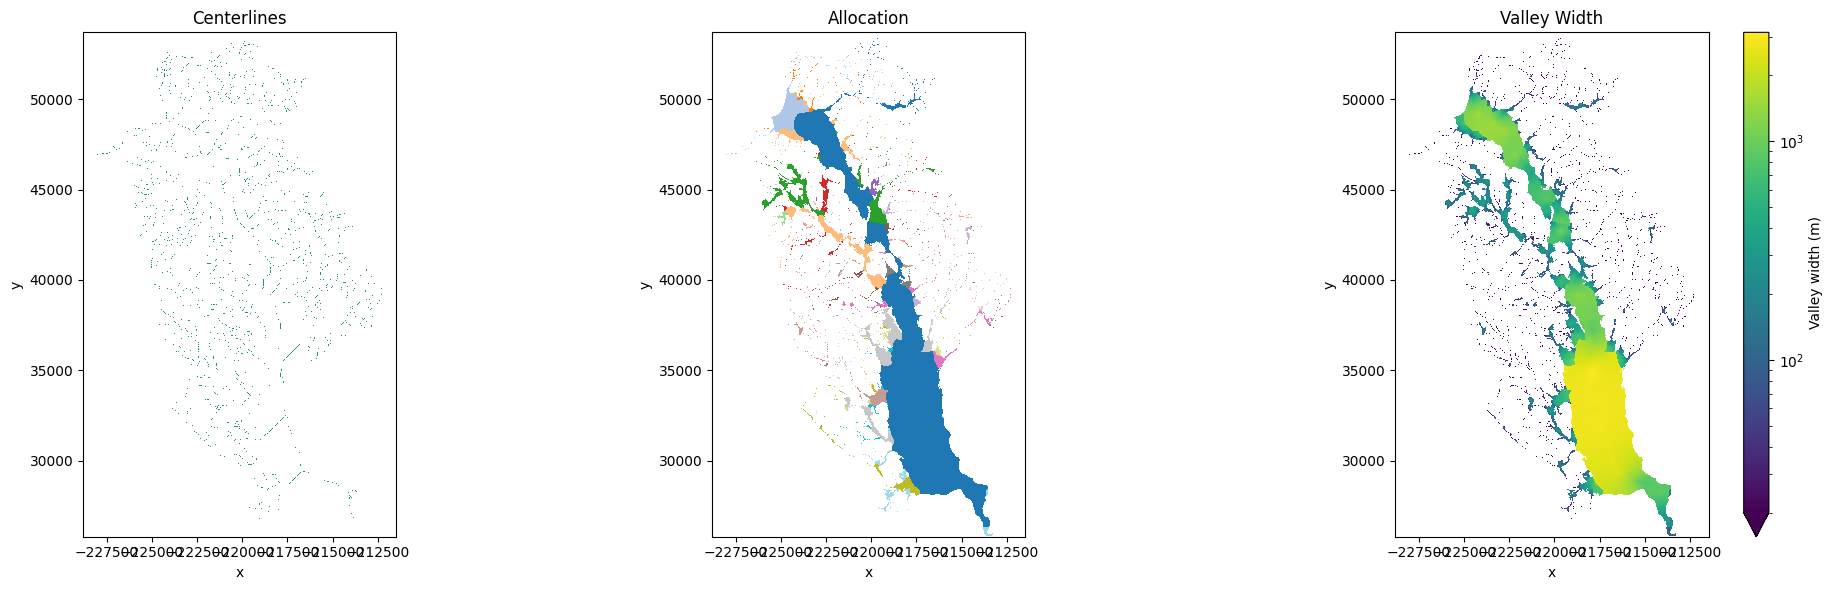

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. Centerlines
results.centerlines.raster.where(results.centerlines.raster > 0).plot(ax=axes[0], add_colorbar=False)
axes[0].set_title("Centerlines")
axes[0].set_aspect("equal")

# 2. Path segmentation
results.allocation.where(results.allocation > 0).plot(ax=axes[1], cmap="tab20", add_colorbar=False)
axes[1].set_title("Allocation")
axes[1].set_aspect("equal")

# 3. Valley widths
norm = LogNorm(vmin=20, vmax=results.widths.max())
results.widths.plot(ax=axes[2], cmap="viridis", norm=norm, cbar_kwargs={"label": "Valley width (m)"})
axes[2].set_title("Valley Width")
axes[2].set_aspect("equal")

plt.tight_layout()

## Part by Part

###  1. Centerlines

In [7]:
centerlines = get_centerlines(region, networks)

In [8]:
centerlines_gdf = centerlines.as_gdf()

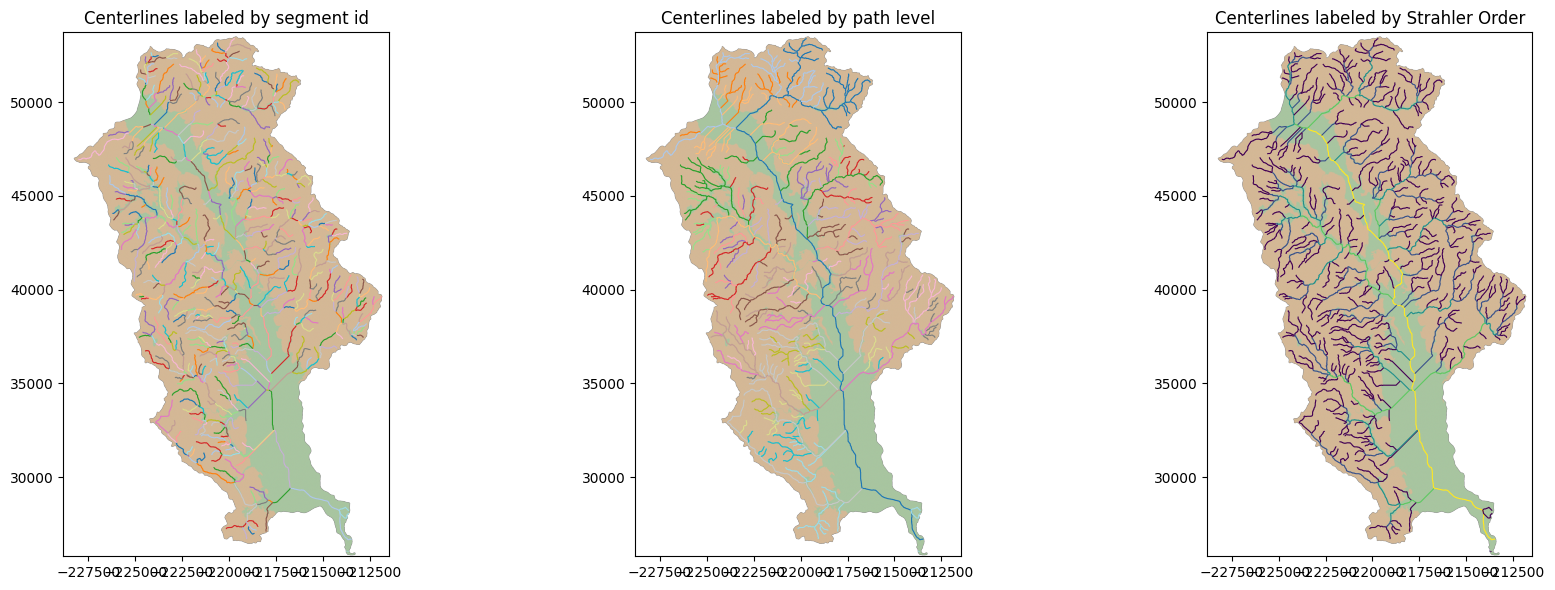

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1. Segment
plot_region(axes[0], region)
centerlines_gdf.plot(ax=axes[0], column='segment_id', linewidth=0.8, cmap='tab20')
axes[0].set_title("Centerlines labeled by segment id")
axes[0].set_aspect("equal")

# 2. Path
plot_region(axes[1], region)
centerlines_gdf.plot(ax=axes[1], column='path_label', linewidth=0.8, cmap='tab20')
axes[1].set_title("Centerlines labeled by path level")
axes[1].set_aspect("equal")

# 2. Strahler
plot_region(axes[2], region)
centerlines_gdf.plot(ax=axes[2], column='strahler_order', linewidth=0.8)
axes[2].set_title("Centerlines labeled by Strahler Order")
axes[2].set_aspect("equal")

plt.tight_layout()

###  2. Allocation

In [10]:
allocation = get_allocation(centerlines, region)
segments = subdivide_paths_into_segments(allocation, centerlines)

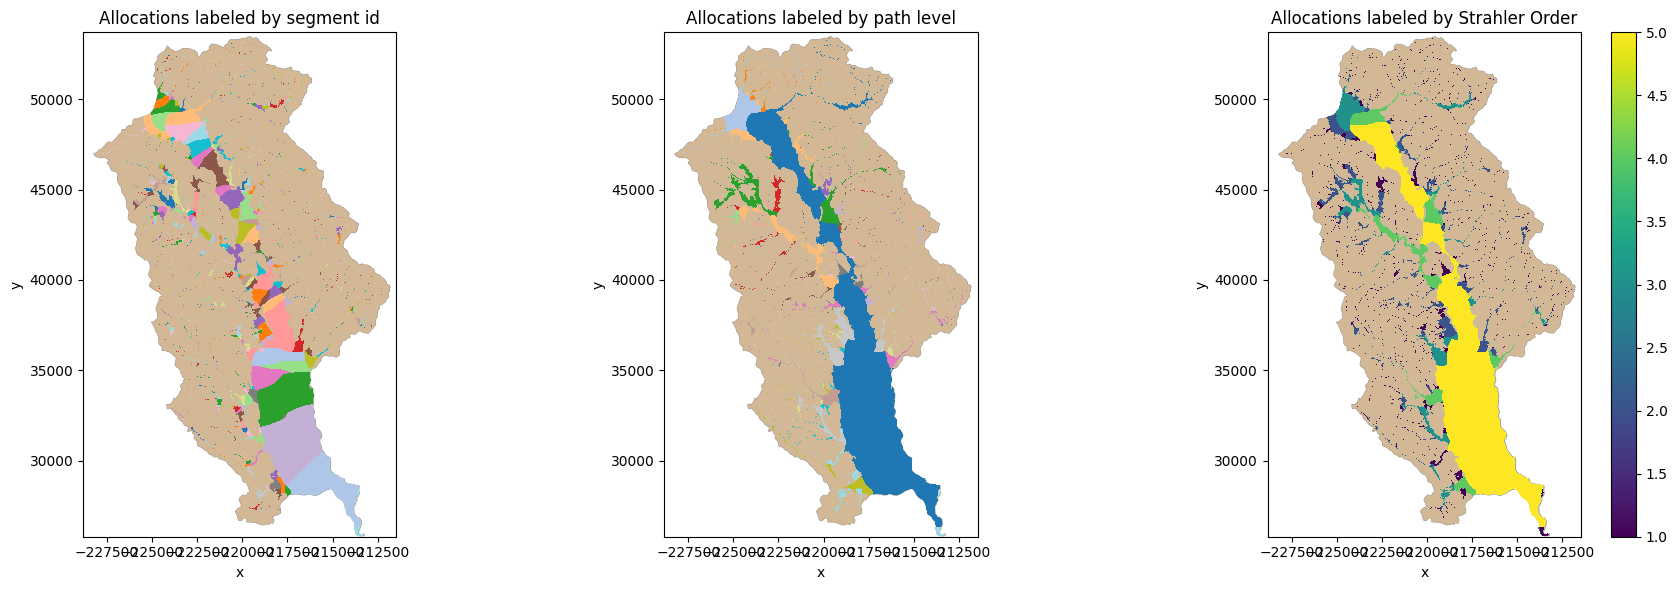

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1. Segment
plot_region(axes[0], region)
segments.where(segments > 0).plot(ax=axes[0], cmap='tab20', add_colorbar=False)
axes[0].set_title("Allocations labeled by segment id")
axes[0].set_aspect("equal")

# 2. Path
plot_region(axes[1], region)
allocation.where(allocation > 0).plot(ax=axes[1], cmap='tab20', add_colorbar=False)
axes[1].set_title("Allocations labeled by path level")
axes[1].set_aspect("equal")

# 2. Strahler
# for each segment_id get strahler order
s_alloc = allocation.copy()
for segment_id in np.unique(segments.values):
    if np.isnan(segment_id) or segment_id == 0:
        continue
    strahler = centerlines.segments.loc[centerlines.segments['segment_id'] == segment_id, 'strahler_order'].iloc[0]
    s_alloc.data[segments == segment_id] = strahler
    
plot_region(axes[2], region)
s_alloc.where(s_alloc > 0).plot(ax=axes[2])
axes[2].set_title("Allocations labeled by Strahler Order")
axes[2].set_aspect("equal")

plt.tight_layout()

###  3. Width

In [12]:
widths_laplace = get_widths(centerlines, region, allocation=allocation, method='laplace')
widths_nn = get_widths(centerlines, region, allocation=allocation, method='nearest')

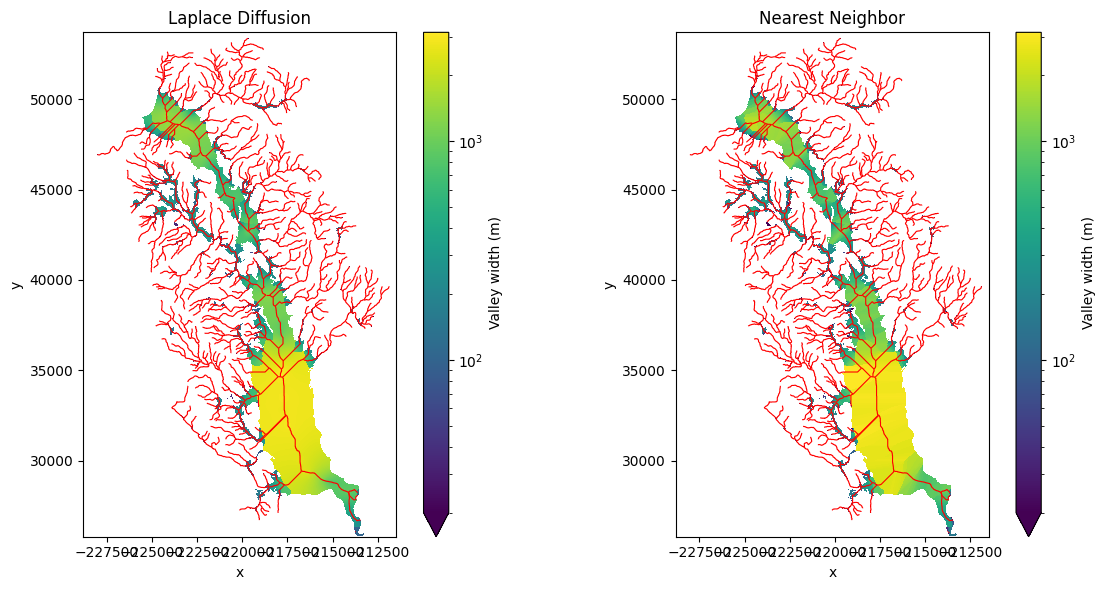

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
norm = LogNorm(vmin=20, vmax=widths_laplace.max())

# 1. Laplace
widths_laplace.plot(ax=axes[0], cmap="viridis", norm=norm, cbar_kwargs={"label": "Valley width (m)"})
centerlines_gdf.plot(ax=axes[0], color="red", linewidth=0.8)
axes[0].set_title("Laplace Diffusion")
axes[0].set_aspect("equal")

# 2. Nearest Neighbor 
widths_nn.plot(ax=axes[1], cmap="viridis", norm=norm, cbar_kwargs={"label": "Valley width (m)"})
centerlines_gdf.plot(ax=axes[1], color="red", linewidth=0.8)
axes[1].set_title("Nearest Neighbor")
axes[1].set_aspect("equal")


plt.tight_layout()